In [1]:
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from sklearn.datasets import make_gaussian_quantiles
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVR

1. Apply the k-nearest neighbons algorithm on the moons dataset. The<br>
number of samples of this dataset is 200. Split the data such that the test<br>
split is 45% of the initial dataset. Set the number of neighbors parameter to<br>
2 and compute the accuracy on the test set. Visualize the decision boundary<br>
of the KNN classifiers using different values for k = {1, 5, 9}.

In [2]:
X, y = make_moons(n_samples=200, noise=0.15, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=66, test_size=0.45)

In [3]:
clf = KNeighborsClassifier(n_neighbors=2)
clf.fit(X_train, y_train)

KNeighborsClassifier(n_neighbors=2)

In [4]:
clf.predict(X_test)

array([0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0,
       0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0,
       1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 0, 1, 1, 0,
       1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0,
       1, 0], dtype=int64)

In [5]:
clf.score(X_test, y_test)

0.9888888888888889

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


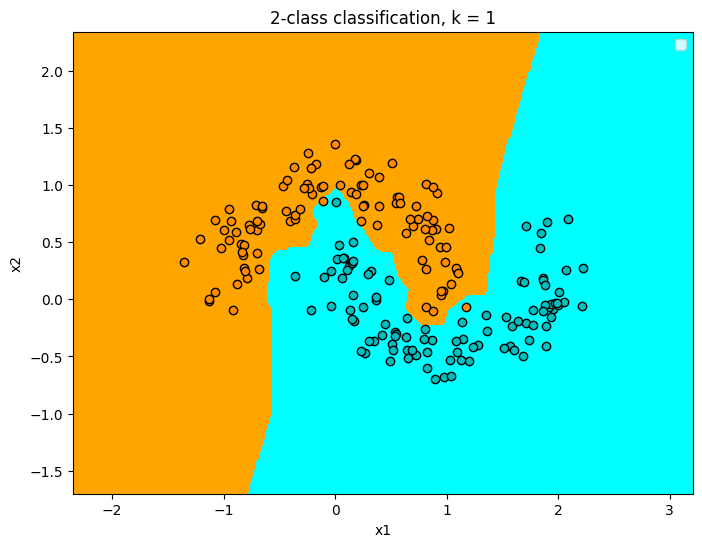

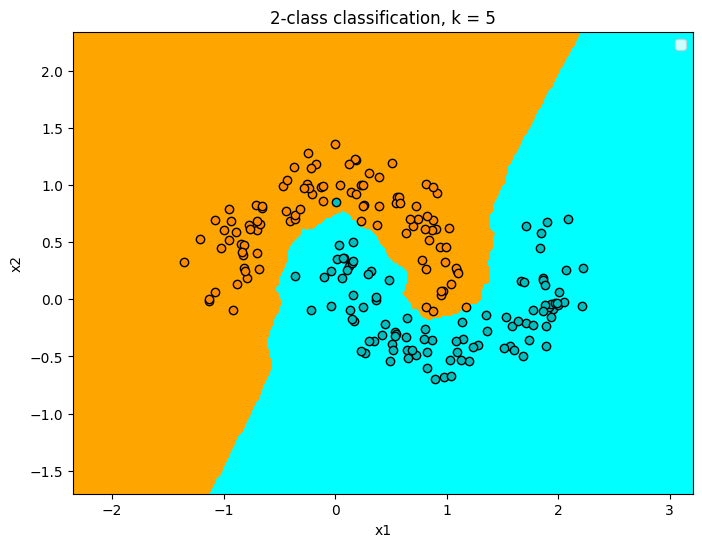

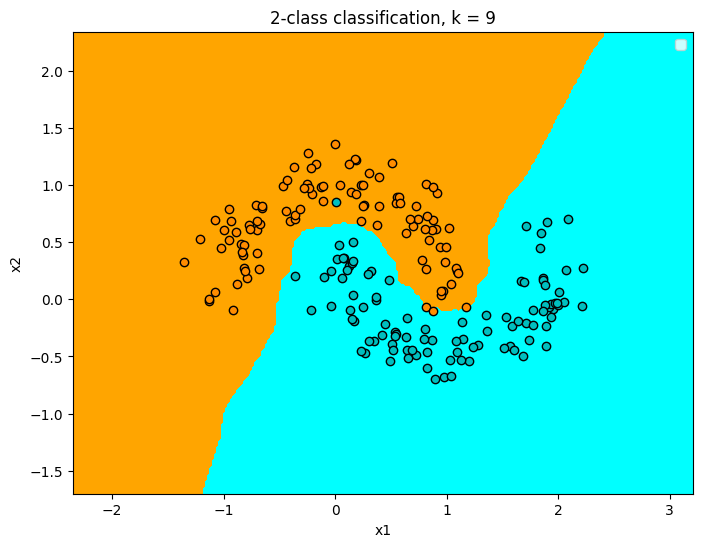

In [6]:
h = 0.02  # Step size in the mesh
# Create color maps
cmap_light = ListedColormap(["orange", "cyan"])
cmap_bold = ["darkorange", "c"]
for n_neighbors in [1, 5, 9]:
    # We create an instance of KNeighborsClassifier and fit the data.
    clf = KNeighborsClassifier(n_neighbors)
    clf.fit(X_train, y_train)

    # Plot the decision boundary. For that, we will assign a color to each
    # point in the mesh [x_min, x_max]x[y_min, y_max].
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])

    # Put the result into a color plot
    Z = Z.reshape(xx.shape)
    plt.figure(figsize=(8, 6))
    plt.contourf(xx, yy, Z, cmap=cmap_light)
    
    # Plot also the training points
    for i in range(2):
      plt.scatter(X[:, 0][y==i], X[:, 1][y==i], c=cmap_bold[i], 
                  edgecolors="black")
    plt.xlim(xx.min(), xx.max())
    plt.ylim(yy.min(), yy.max())
    plt.title("2-class classification, k = %i" % (n_neighbors))
    plt.xlabel("x1")
    plt.ylabel("x2")
    plt.legend()
plt.show()

2. Use the following dataset:<br>
X1, y1 = make_gaussian_quantiles(cov=7.,n_samples=250, n_features=2, n_classes=3, random_state=1)<br>
in order to apply the nonlinear SVM classification. Use the polynornial kernel<br>
and set the degree, coef0, and C parameters to 3, 10, and 5 respectively.<br>
Plot the decision boundary of the nonlinear SVM classification.

In [7]:
X1, y1 = make_gaussian_quantiles(cov=7.,n_samples=250, n_features=2, n_classes=3, random_state=1)

In [8]:
poly_kernel_svm_clf = Pipeline([
        ("scaler", StandardScaler()),
        ("svm_clf", SVC(kernel="poly", degree=3, coef0=10, C=5))
    ])
poly_kernel_svm_clf.fit(X1, y1)

Pipeline(steps=[('scaler', StandardScaler()),
                ('svm_clf', SVC(C=5, coef0=10, kernel='poly'))])

In [9]:
def plot_dataset(X, y, axes):
    plt.plot(X[:, 0][y==0], X[:, 1][y==0], "bs")
    plt.plot(X[:, 0][y==1], X[:, 1][y==1], "r^")
    plt.plot(X[:, 0][y==2], X[:, 1][y==2], "gs")
    plt.axis(axes)
    plt.grid(True, which='both')
    plt.xlabel(r"$x_1$", fontsize=20)
    plt.ylabel(r"$x_2$", fontsize=20, rotation=0)

In [10]:
def plot_predictions(clf, axes):
    x0s = np.linspace(axes[0], axes[1], 100)
    x1s = np.linspace(axes[2], axes[3], 100)
    x0, x1 = np.meshgrid(x0s, x1s)
    X = np.c_[x0.ravel(), x1.ravel()]
    y_pred = clf.predict(X).reshape(x0.shape)
    plt.contourf(x0, x1, y_pred, cmap=plt.cm.brg, alpha=0.2)

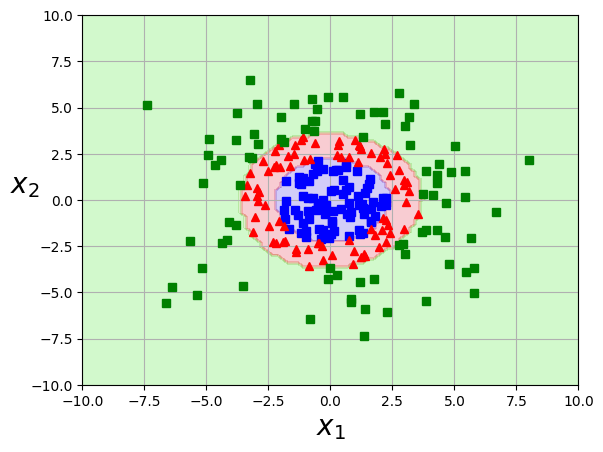

In [11]:
plot_predictions(poly_kernel_svm_clf, [-10, 10, -10, 10])
plot_dataset(X1, y1, [-10, 10, -10, 10])
plt.show()

3. Apply linear SVM regression to the following dataset:<br>
X = 6 * np.random.rand(n, 1)<br>
y = (1 - 2 * X + np.random.randn(n, 1)).ravel()<br>
Set the width of the margin to 0.8 and plot the fit line.<br>

In [36]:
n = 50
X = 6 * np.random.rand(n, 1)
y = (1 - 2 * X + np.random.randn(n, 1)).ravel()

In [37]:


svm_reg = LinearSVR(epsilon=0.8, random_state=42)
svm_reg.fit(X, y)

def find_support_vectors(svm_reg, X, y):
    y_pred = svm_reg.predict(X)
    off_margin = (np.abs(y - y_pred) >= svm_reg.epsilon)
    return np.argwhere(off_margin)

svm_reg.support_ = find_support_vectors(svm_reg, X, y)

c:\Python310\lib\site-packages\sklearn\svm\_base.py:1244: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


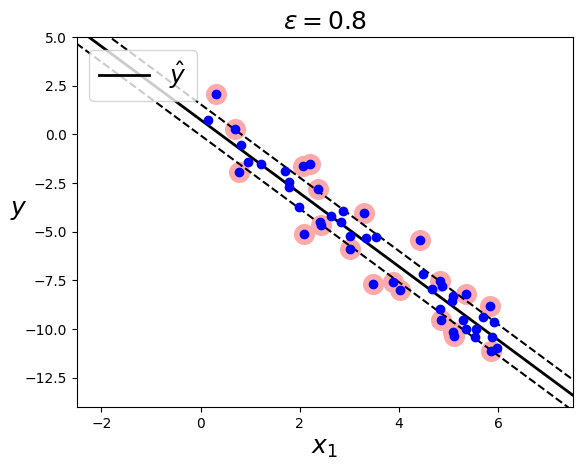

In [41]:
def plot_svm_regression(svm_reg, X, y, axes):
    x1s = np.linspace(axes[0], axes[1], 100).reshape(100, 1)
    y_pred = svm_reg.predict(x1s)
    plt.plot(x1s, y_pred, "k-", linewidth=2, label=r"$\hat{y}$")
    plt.plot(x1s, y_pred + svm_reg.epsilon, "k--")
    plt.plot(x1s, y_pred - svm_reg.epsilon, "k--")
    plt.scatter(X[svm_reg.support_], y[svm_reg.support_], s=200, facecolors='#FFAAAA')
    plt.plot(X, y, "bo")
    plt.xlabel(r"$x_1$", fontsize=18)
    plt.legend(loc="upper left", fontsize=18)
    plt.axis(axes)

plot_svm_regression(svm_reg, X, y, [-2.5, 7.5, -14, 5])
plt.title(r"$\epsilon = {}$".format(svm_reg.epsilon), fontsize=18)
plt.ylabel(r"$y$", fontsize=18, rotation=0)
plt.show()